In [ ]:
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    requirements = [
        'langchain==1.3.13',
        'langchain-core==1.4.9',
        'langchain-openai==1.3.5',
        'langsmith==0.9.5',
        'python-dotenv==1.0.1',
        'pandas==2.2.3',
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *requirements])
else:
    print('Entorno local detectado. Usa el entorno uv (.venv) descrito en README para manejar dependencias.')


# Versionamiento y mantenimiento de Prompts

## Importaciones y variables
Vamos a usar Langsmith + Langchain + OpenAI para esta demo de evaluaciones y sus tipos.


In [ ]:
import os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
os.environ.setdefault('LANGSMITH_PROJECT', os.getenv('LANGSMITH_PROJECT', 'Test Evaluation'))
os.environ.setdefault('LANGSMITH_TRACING', 'true')

if IN_COLAB:
    from google.colab import userdata

    for key in ('OPENAI_API_KEY', 'LANGSMITH_API_KEY'):
        secret_value = userdata.get(key)
        if not secret_value:
            raise ValueError(f'Falta la variable {key} en el gestor de secretos de Colab')
        os.environ[key] = secret_value
else:
    try:
        from dotenv import load_dotenv
    except ImportError as exc:  # pragma: no cover
        raise ImportError('Instala python-dotenv para cargar las variables locales.') from exc
    env_file = Path('.env')
    if env_file.exists():
        load_dotenv(env_file)
        print('Variables cargadas desde .env')
    else:
        print('No se encontró .env en el root. Se usarán las variables de entorno del sistema.')

missing_keys = [key for key in ('OPENAI_API_KEY', 'LANGSMITH_API_KEY') if not os.getenv(key)]
if missing_keys:
    raise EnvironmentError(f'Faltan variables requeridas: {", ".join(missing_keys)}')


## Caso 1: Usar un prompt directo de prompt hub

Comencemos buscando en prompt hub algun prompt que nos interese

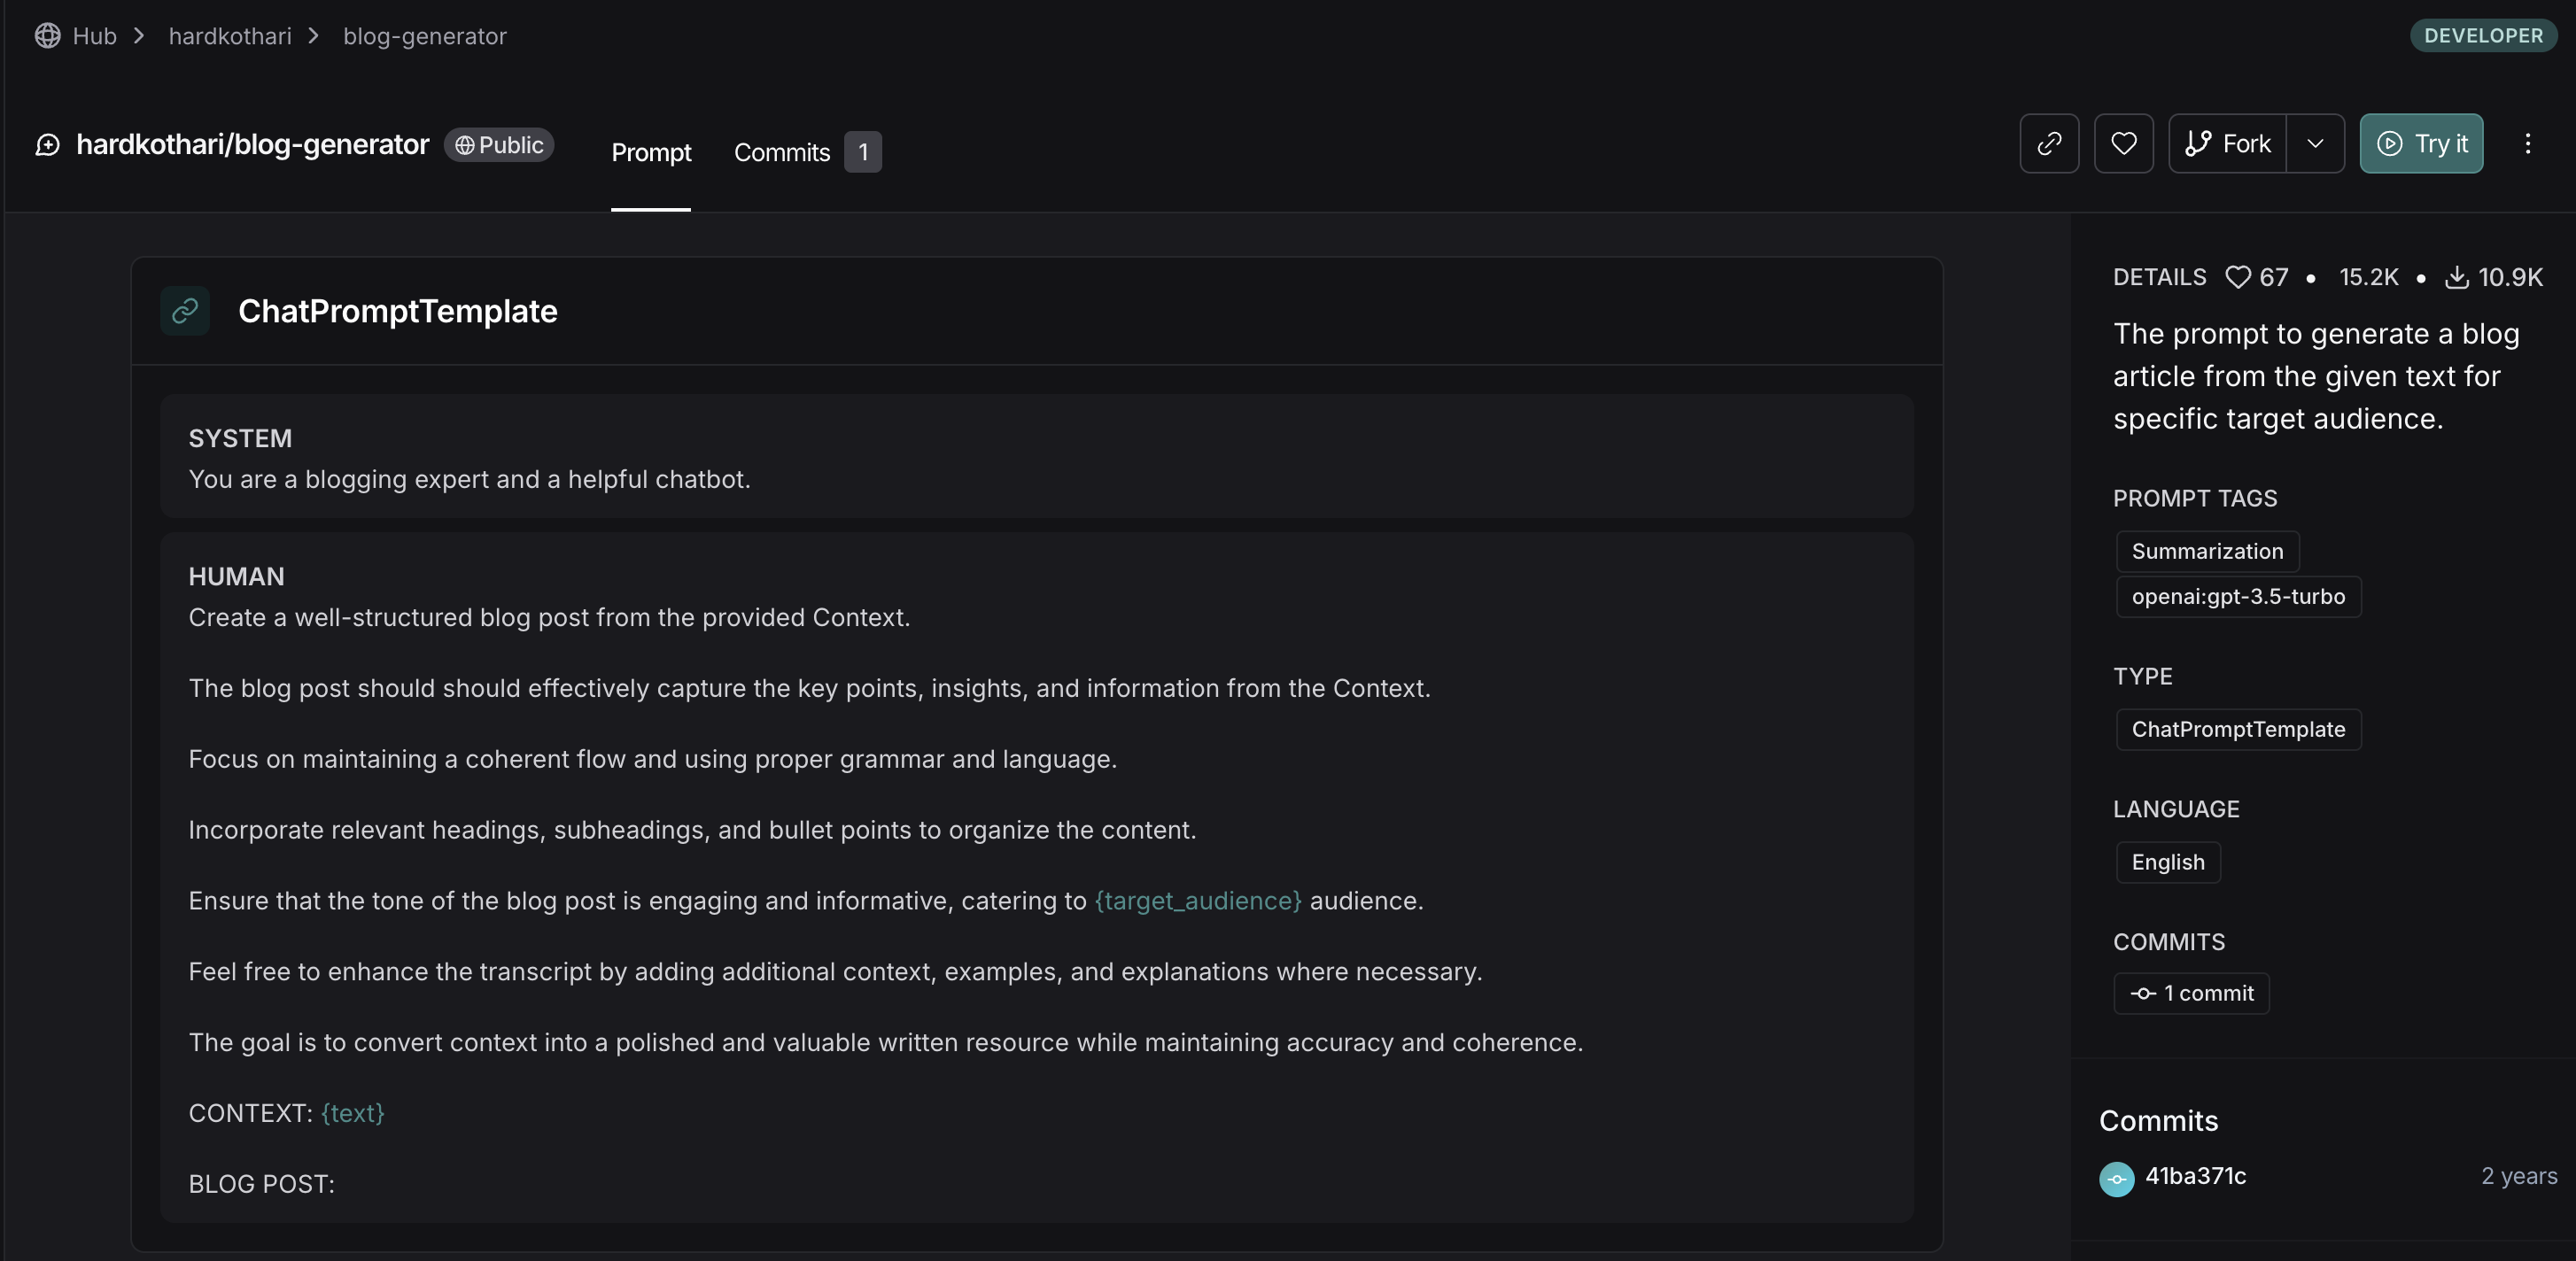

In [ ]:
from langsmith import Client

# La API key se toma de LANGSMITH_API_KEY (configurada en la celda anterior).
client = Client()
prompt = client.pull_prompt("hardkothari/blog-generator", include_model=True, dangerously_pull_public_prompt=True)
prompt


Revisemos el contenido del prompt

In [ ]:
for message in prompt.messages:
  print(type(message), message.prompt.template)

### Usemos el prompt!
Este prompt se puede usar en chaind, agentes o directamente con LLMs commo cualquier objeto runnebla de Langchain.

Para testearlo vamos a bajar una noticia (podria ser cualquier testo) y generar un blog

In [ ]:
# descargamos el texto
file_name = 'ai_news.txt'
with open(file_name, 'r', encoding='utf-8') as file:
    news_text = file.read()
news_text

In [ ]:
from langchain_openai import ChatOpenAI

# construyendo una cadena que use el prompt
model_name = 'gpt-5-mini'
model = ChatOpenAI(model=model_name)  # gpt-5* solo admite temperature=1; se omite el parámetro

chain = prompt | model


# Usemos el modelo para hacer es blog para una audiencia especifica
response = chain.invoke({'target_audience': '6 year old Chilean students (only read in simple spanish)',
              'text': news_text })
print(response.content)


## Caso 2: Generar y crear una nueva version del prompt

Para esto, vamos a generar un fork del prompt publico base (tambien puedes crear un prompt nuevo desde cero)

Para esto:

1. Entra a prompt hub y dale a fork:


2. Llamalo como quieras (puedes dejarlo privado o publico)

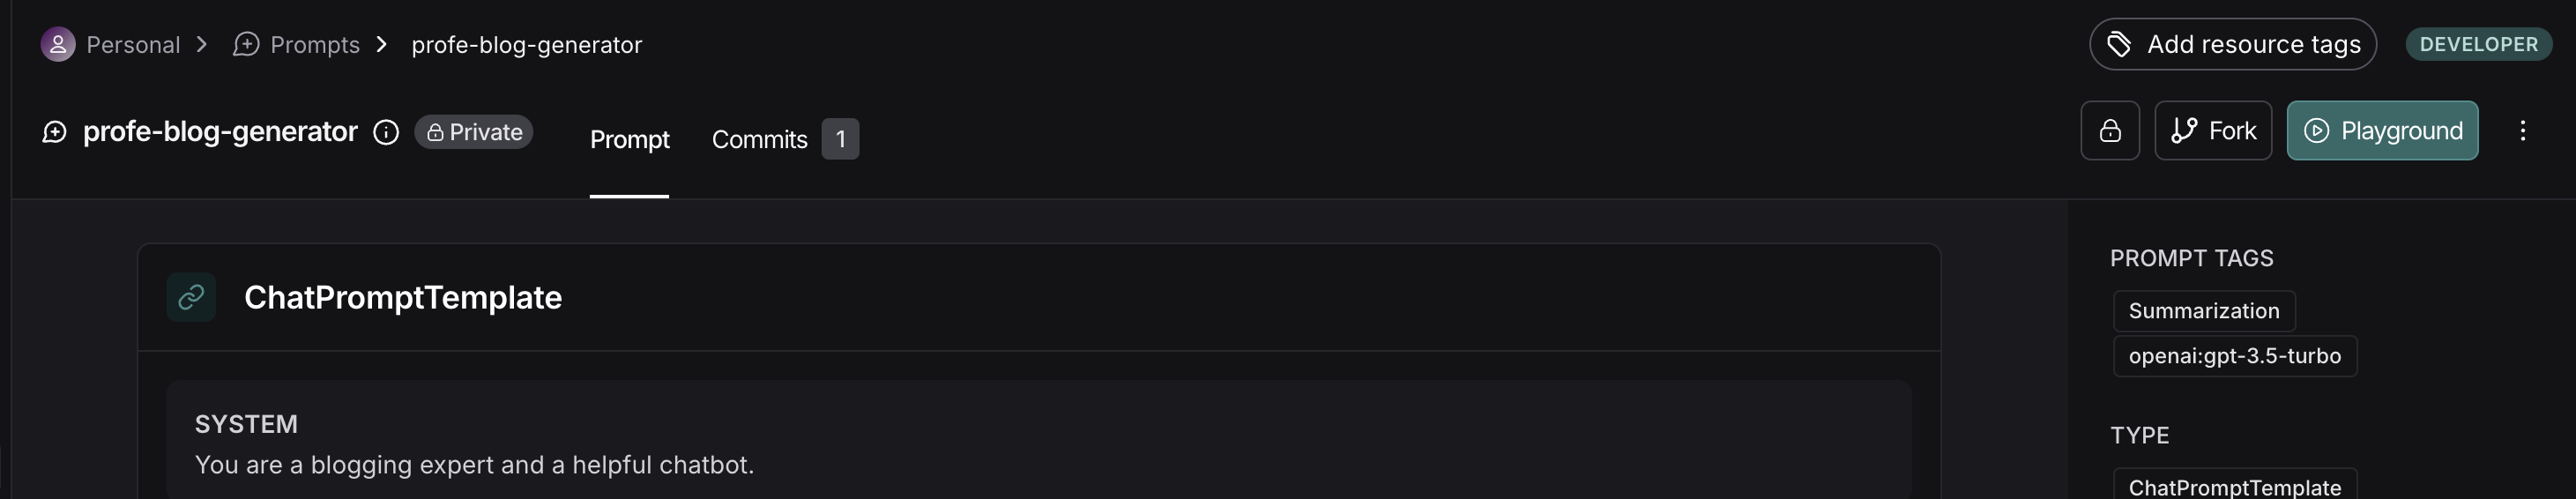


3. Editalo en el prompt playgrond
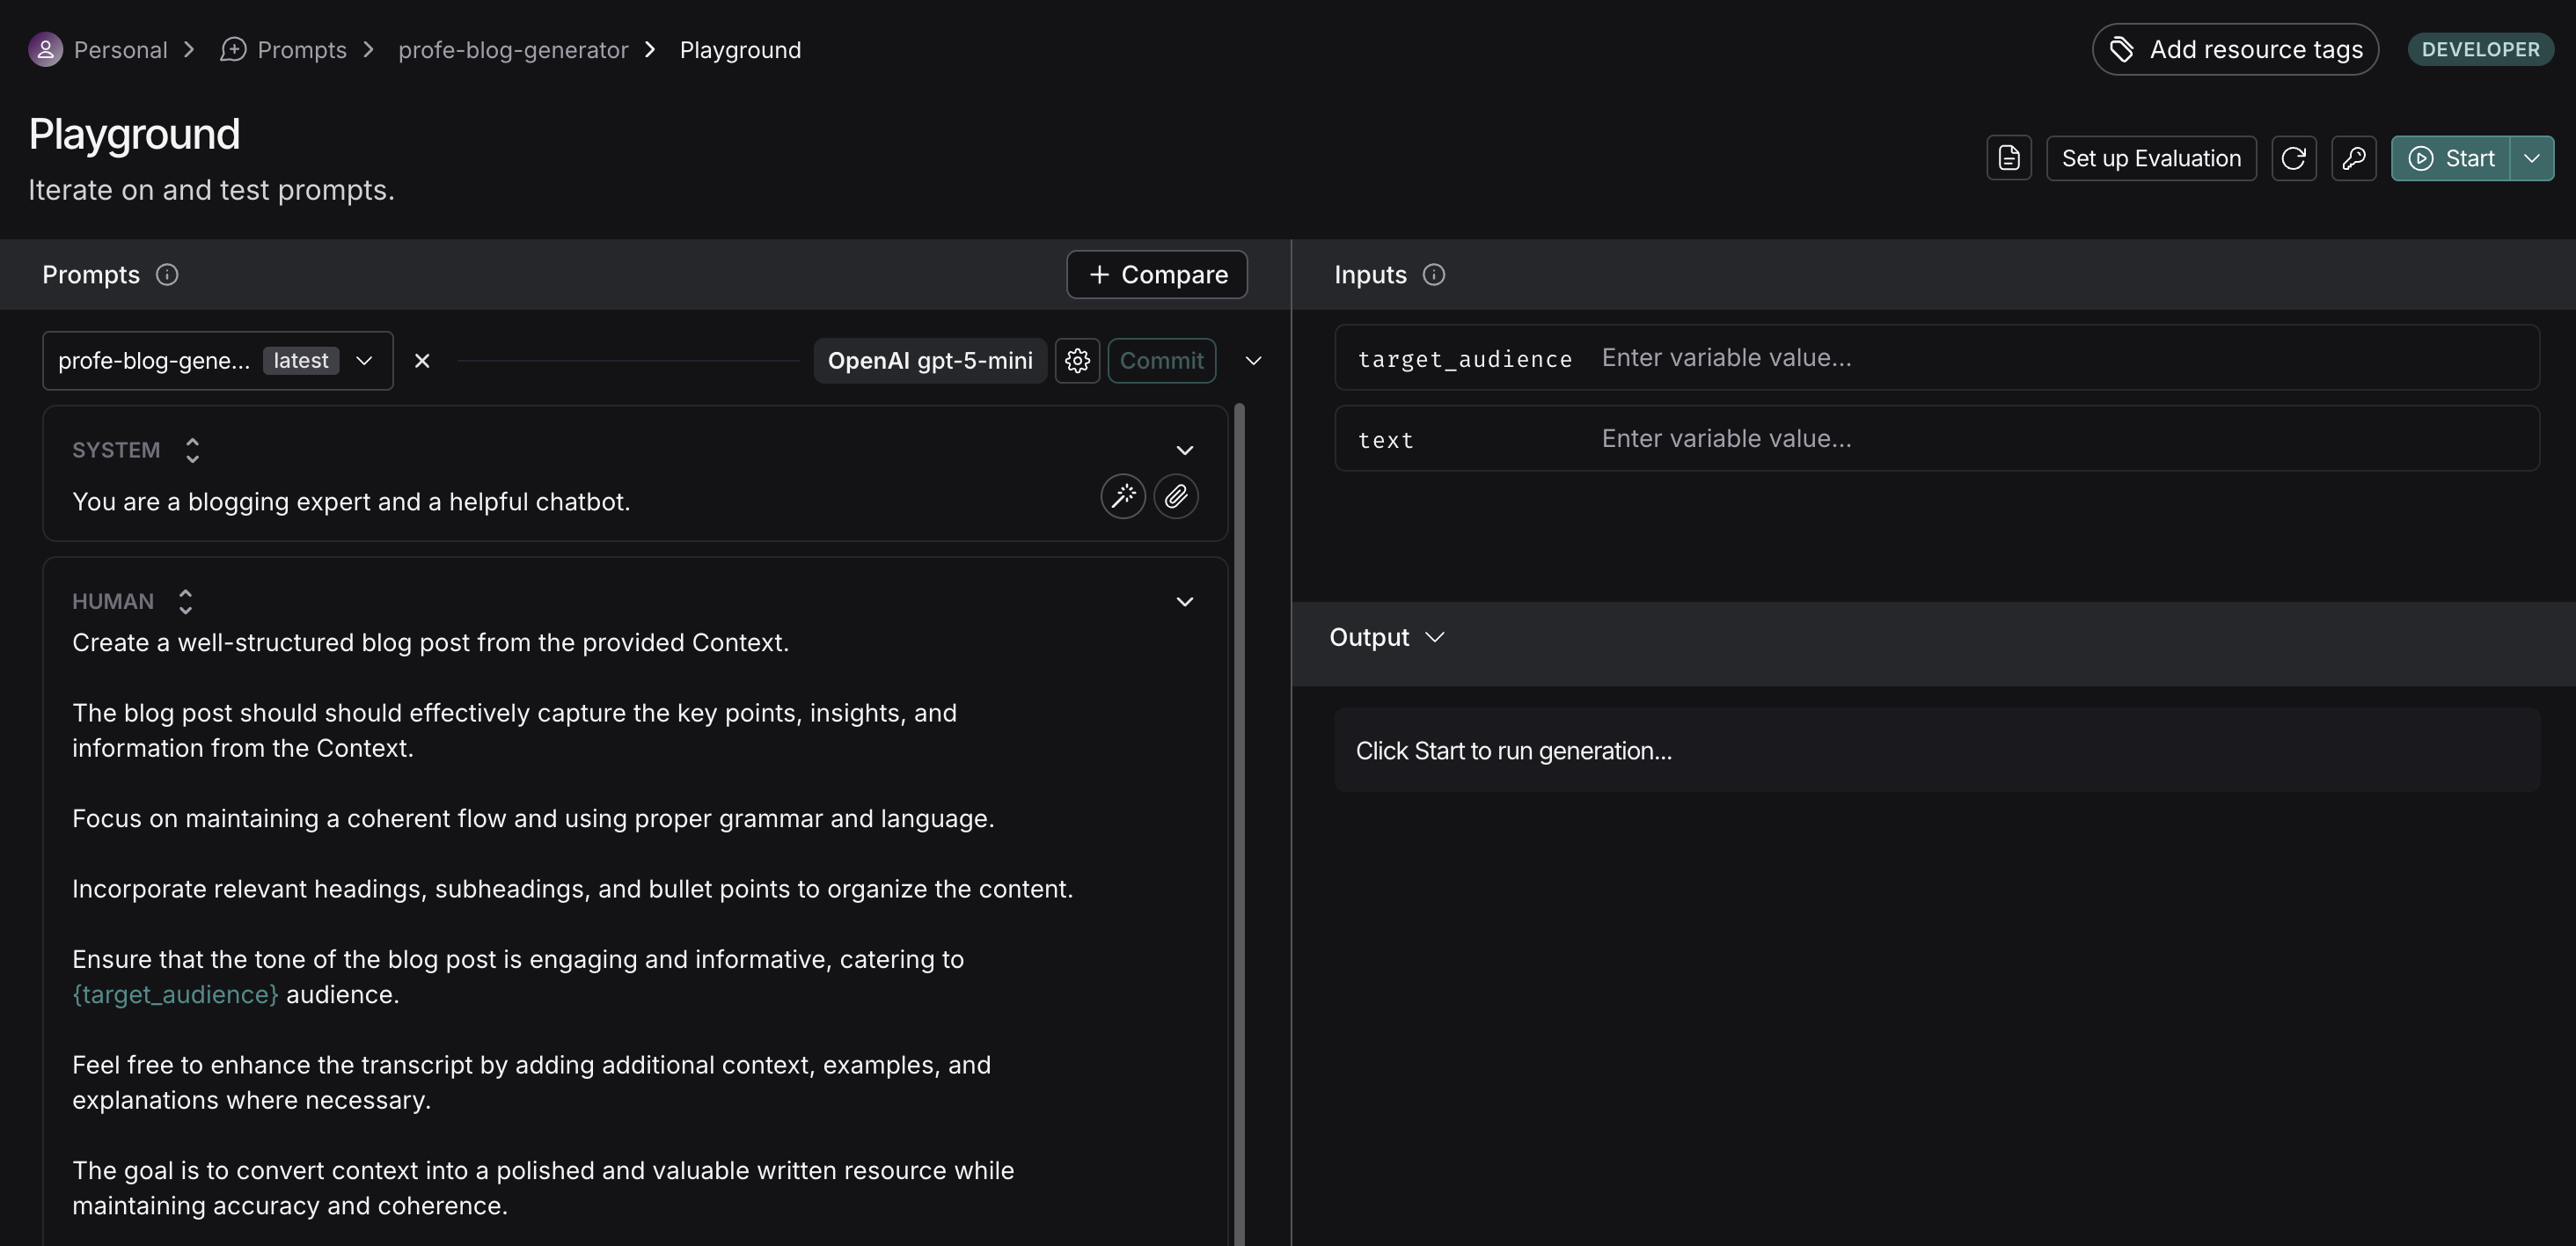


4. Guardalo como un nuevo commit:
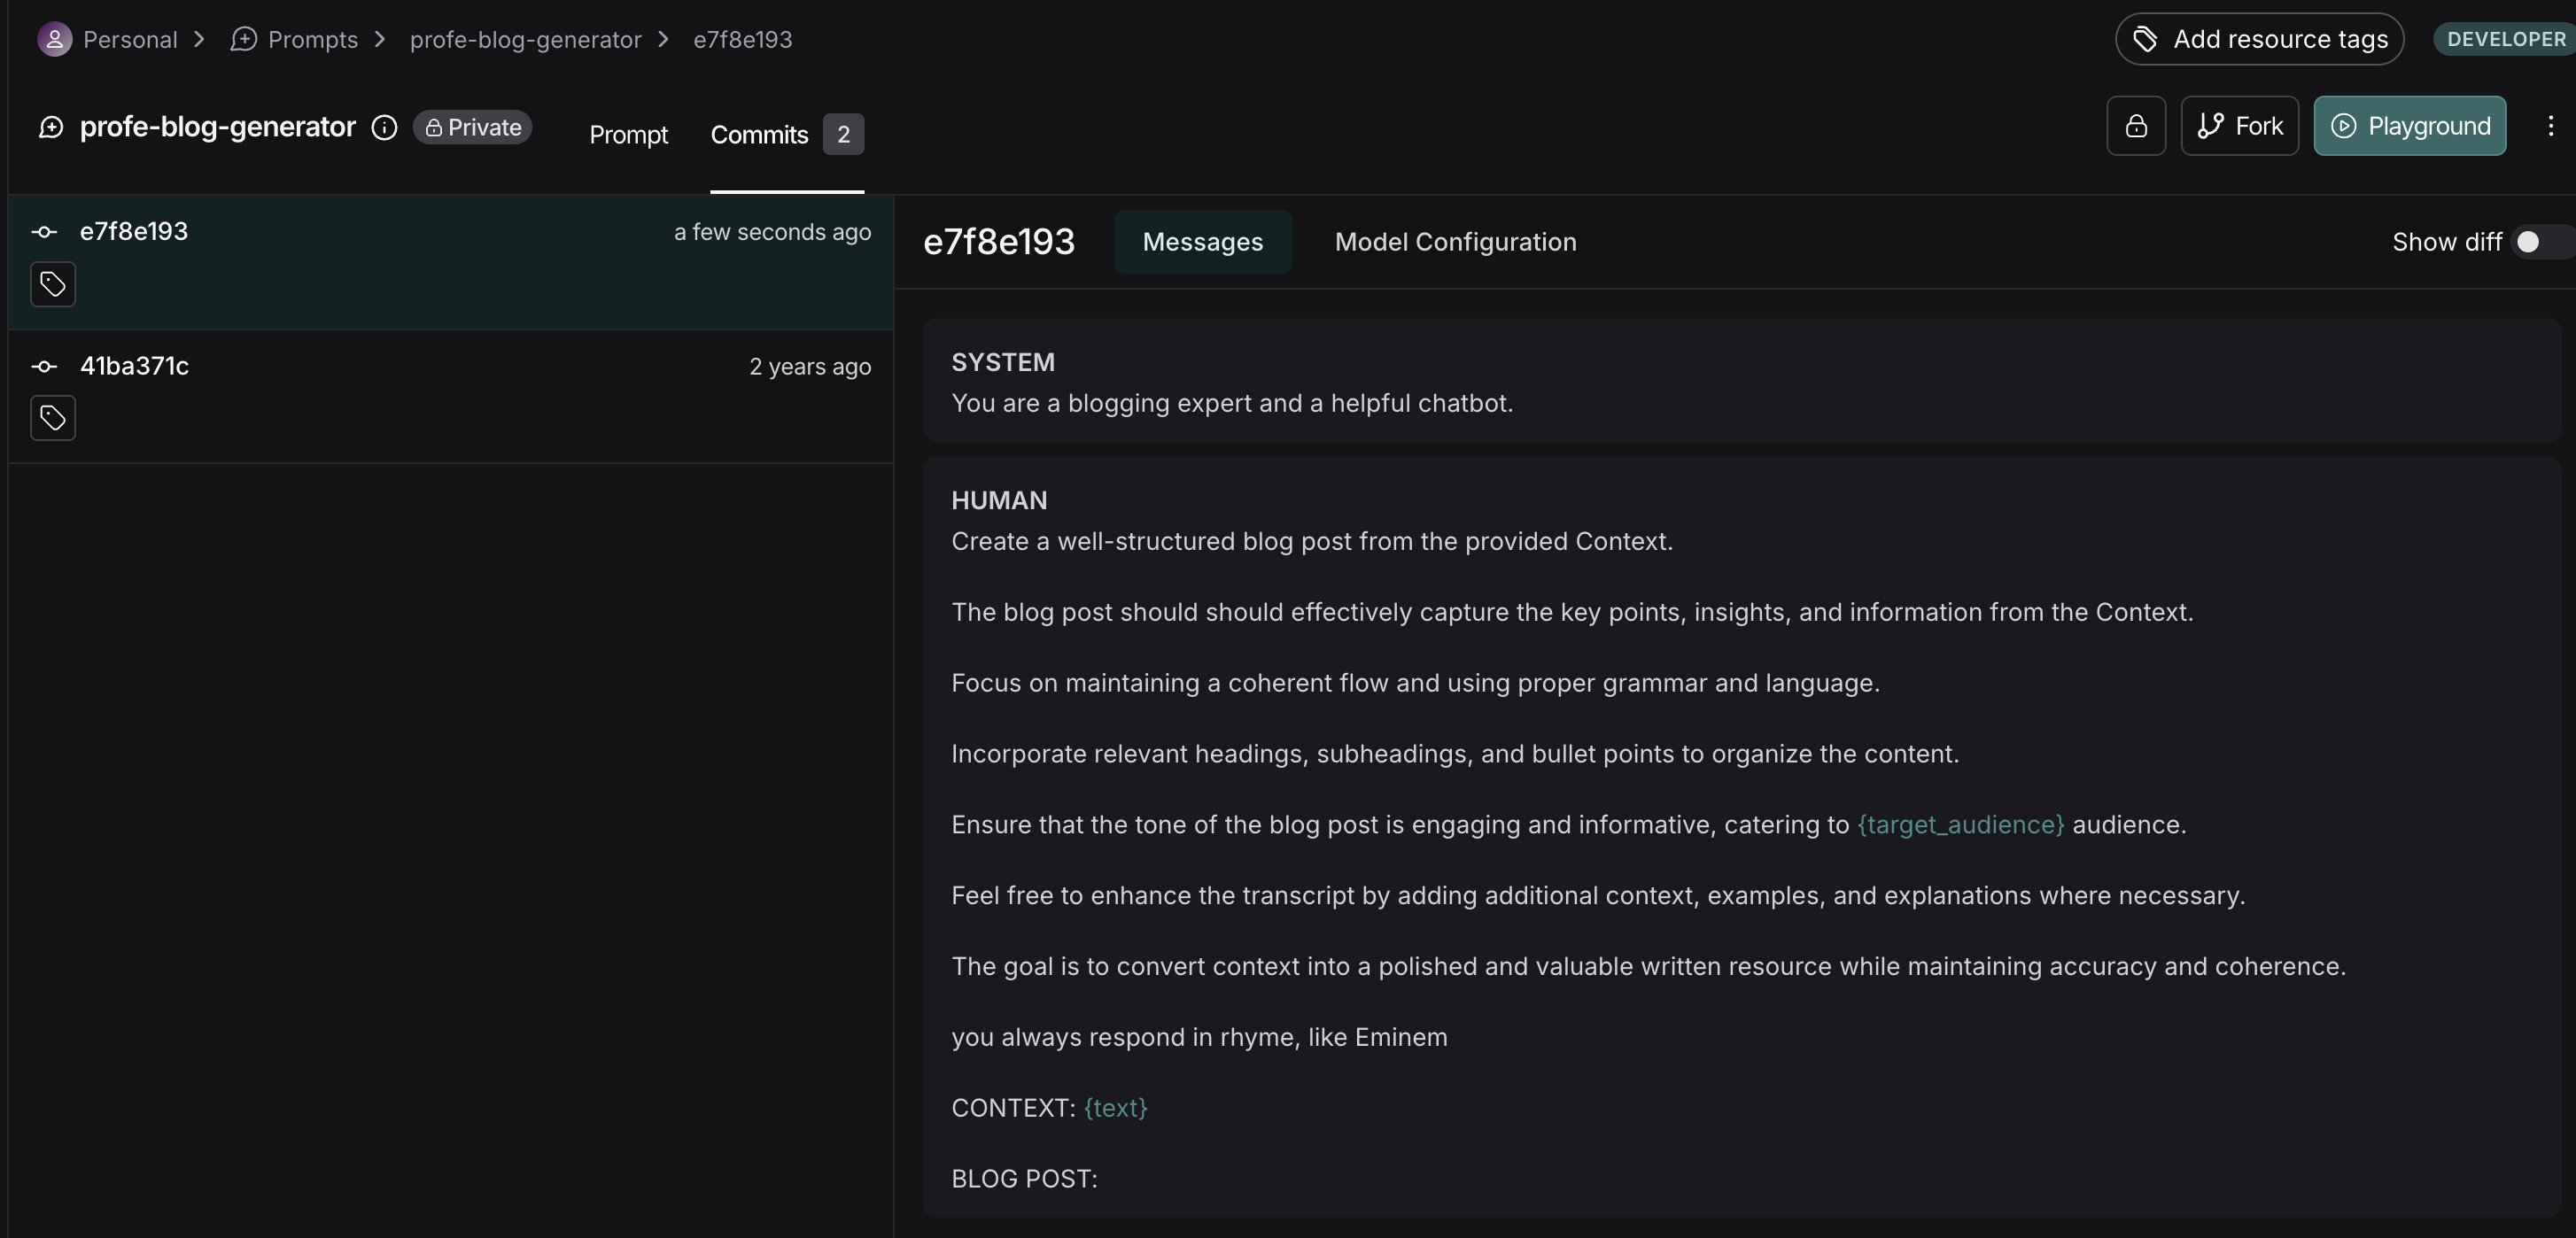

Ahora tu nuevo prompt editado va a estar disponible bajo el nombre que generaste.

> **⚠️ Reemplaza el nombre del prompt.** Las celdas siguientes usan `profe-blog-enerator`
> (y el commit `25fb38a3`), que es el prompt **privado del instructor**: no podrás descargarlo.
> Cámbialo por el nombre de **tu** fork y, para la versión fijada, por **tu** hash de commit
> (lo encuentras en el Prompt Hub, en el historial de commits del prompt).

In [ ]:
new_prompt = client.pull_prompt("ejemplo_clase:dd89d0ad")
for message in new_prompt.messages:
  print(type(message), message.prompt.template)

Tambien puedes acceder a algun commit especifico del prompt (util para apuntar a una version especifica en producción)

In [ ]:
new_prompt = client.pull_prompt("ejemplo_clase:41ba371c")
for message in new_prompt.messages:
  print(type(message), message.prompt.template)

Este nuevo prompt se puede usar de la misma forma que el prompt inicial

In [ ]:
chain = new_prompt | model

response = chain.invoke({'target_audience': '18 year old Chilean students',
              'text': news_text })
print(response.content)